<a href="https://colab.research.google.com/github/viruksha-as/Medical-insurance-prediction/blob/main/Medical_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

TASK 0

In [ ]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test sets
from sklearn.model_selection import train_test_split

# to build a linear regression model
from sklearn.linear_model import LinearRegression

# to check a regression model's performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

LOAD THE DATA

TASK 1

In [ ]:
data = pd.read_csv("insurance.csv")  # Load dataset


TASK 2

DATA OVERVIEW

In [ ]:
data.head()                          # Show first 5 rows


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data.shape

(1338, 7)

CHECKING DATA ATTRIBUTES

CHECKING MISSING VALUES

In [ ]:
data.info()                          # Data types & null values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


CHECKING STATISTICAL SUMMARY

In [ ]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
#Statistical Interpretation (Mean–Median–Mode)

#1 Age → Mean ≈ Median → nearly symmetric distribution, no strong skewness
#2 BMI → Mean ≈ Median ≈ Mode → approximately normal distribution with slight right skew
#3 Children → Mode < Median < Mean → slightly right-skewed distribution
#4 Charges → Mean » Median » Mode → strong right-skewed distribution
#5 High charges create outliers, pulling the mean upward
#6 Age & BMI are more evenly distributed compared to charges

In [ ]:
data.isnull().sum()                  # Check for missing values


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


TASK 3

EXPLORATORY DATA ANALYSIS

UNIVARIATE ANALYSIS

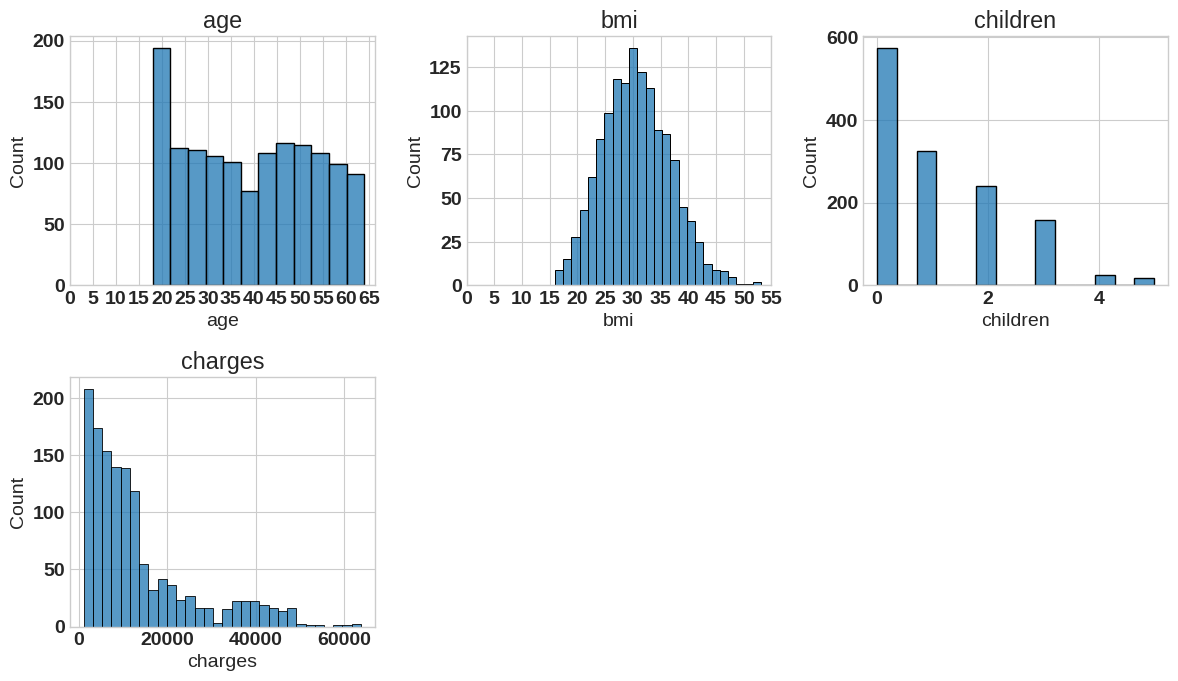

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_cols = data.select_dtypes(include='number').columns

plt.figure(figsize=(12, 10))

for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data[col], kde=False)
    plt.title(col)

    # Set custom x-axis ticks for age and bmi
    if col in ['age', 'bmi']:
        min_val = int(data[col].min())
        max_val = int(data[col].max())
        plt.xticks(np.arange(0, max_val + 5, 5))  # 5,10,15,20...

plt.tight_layout()
plt.show()



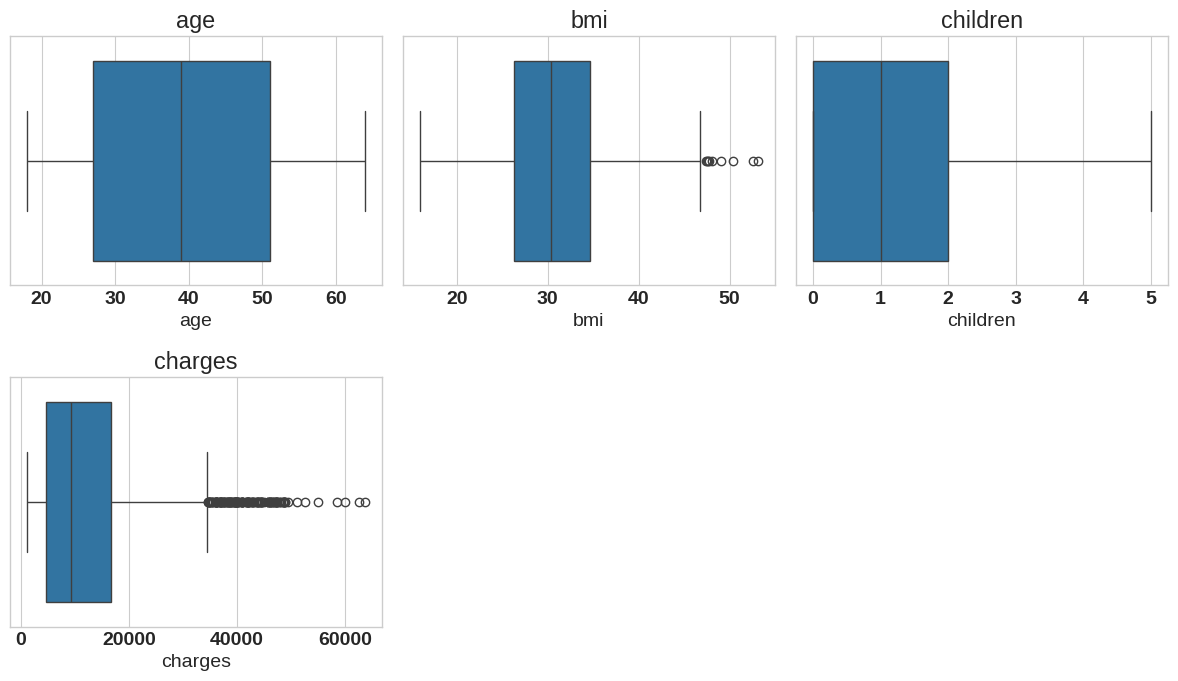

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data.select_dtypes(include='number').columns

plt.figure(figsize=(12, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()


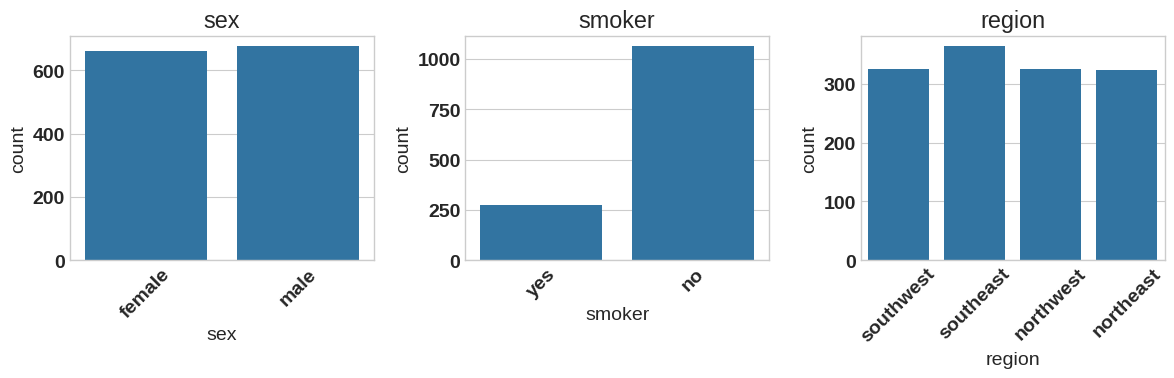

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = data.select_dtypes(include='object').columns

plt.figure(figsize=(12, 10))

for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=data[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
data.dtypes


,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['sex'] = le.fit_transform(data['sex'])
data['smoker'] = le.fit_transform(data['smoker'])
data['region'] = le.fit_transform(data['region'])

data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


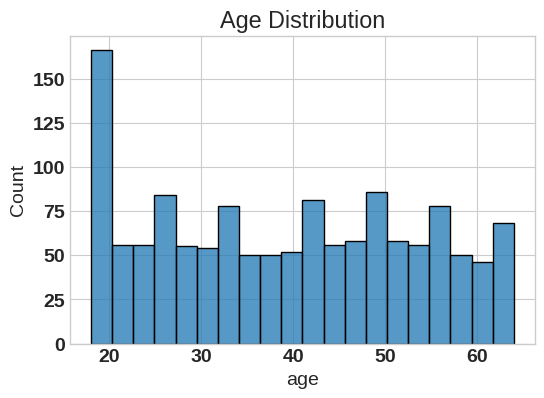

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.histplot(data['age'], bins=20)
plt.title("Age Distribution")
plt.show()


📌 Inference

Age is fairly evenly spread

No extreme spikes

Indicates a balanced adult population

Distribution is close to symmetric

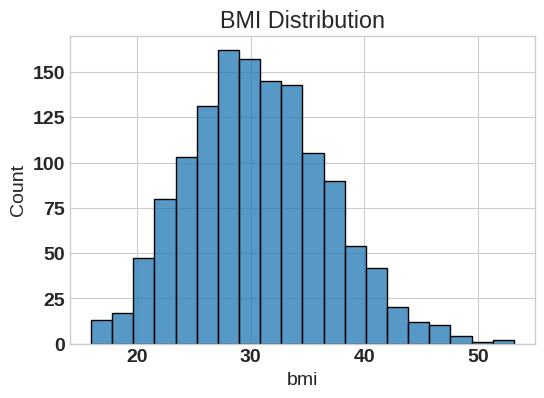

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data['bmi'], bins=20)
plt.title("BMI Distribution")
plt.show()


📌 Inference

BMI follows an approximately normal distribution

Slight right tail due to higher BMI values

Indicates presence of overweight and obese individuals

No sharp discontinuities → smooth spread

/tmp/ipython-input-876/1654318974.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


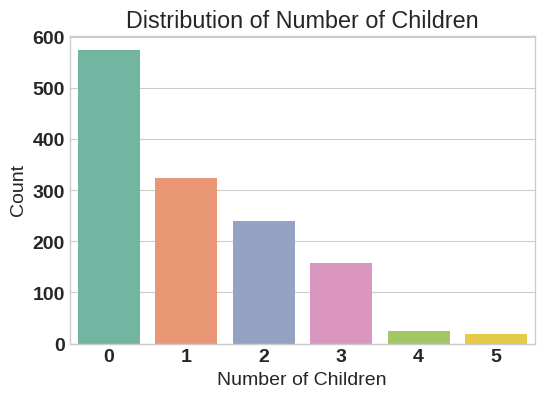

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='children',
    data=data,
    palette='Set2'
)
plt.title("Distribution of Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Count")
plt.show()


📌 Inference

Most individuals have 0, 1, or 2 children

Frequency drops as children count increases

Distribution is right-skewed

Discrete and limited range

/tmp/ipython-input-876/454789521.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


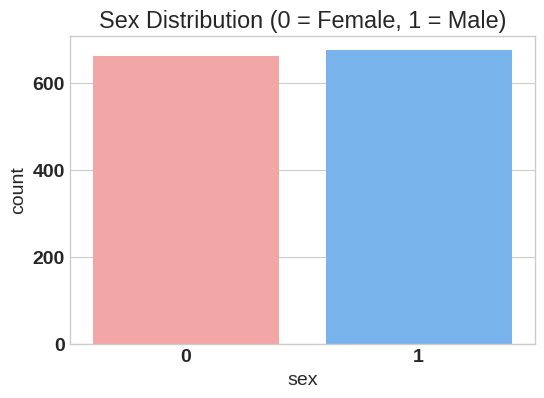

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='sex',
    data=data,
    palette=['#ff9999', '#66b3ff']
)
plt.title("Sex Distribution (0 = Female, 1 = Male)")
plt.show()


📌 Inference

Male and female counts are almost balanced

No strong gender bias in the dataset

Suitable for unbiased analysis

/tmp/ipython-input-876/2335227121.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


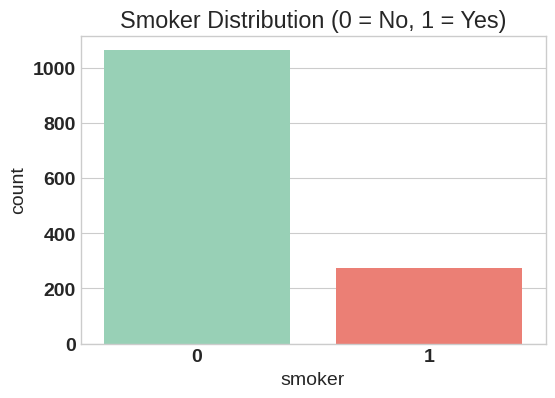

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='smoker',
    data=data,
    palette=['#8fd9b6', '#ff6f61']
)
plt.title("Smoker Distribution (0 = No, 1 = Yes)")
plt.show()


📌 Inference

Majority are non-smokers

Smokers form a smaller but significant group

Important variable due to strong impact on charges

/tmp/ipython-input-876/1205921589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


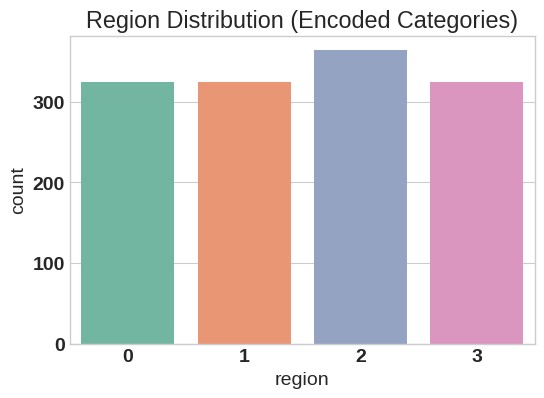

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='region',
    data=data,
    palette='Set2'
)
plt.title("Region Distribution (Encoded Categories)")
plt.show()


📌 Inference

All regions are fairly evenly represented

No dominant region

Region alone may have limited predictive power

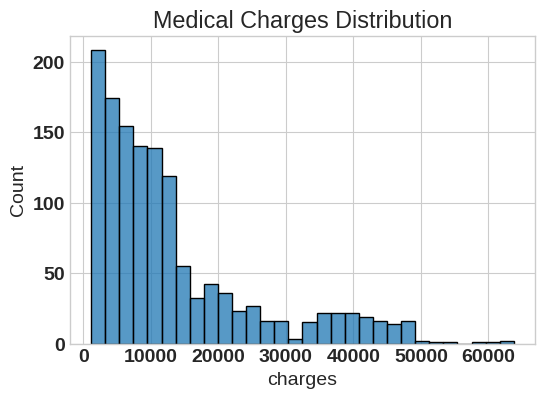

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data['charges'], bins=30)
plt.title("Medical Charges Distribution")
plt.show()


📌 Inference

Strong right-skewed distribution

Majority have low to moderate charges

Few individuals have very high medical costs

Presence of outliers

Mean is pulled upward

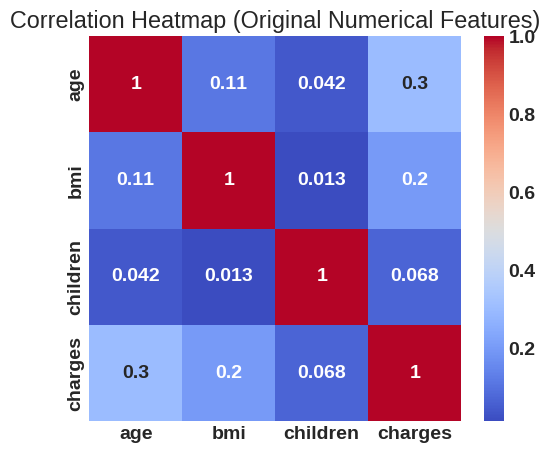

In [ ]:
# selecting only original numerical columns
num_cols = ['age', 'bmi', 'children', 'charges']

corr = data[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Original Numerical Features)")
plt.show()


Inference: Heatmap with ONLY original numerical features

(age, bmi, children, charges)

What this heatmap says

Age vs Charges (≈ 0.30)
→ Moderate positive relationship
→ As age increases, medical charges tend to increase.

BMI vs Charges (≈ 0.20)
→ Weak to moderate positive relationship
→ Higher BMI is associated with higher medical costs, but not strongly.

Children vs Charges (≈ 0.07)
→ Very weak relationship
→ Number of children has little effect on medical charges.

Age vs BMI / Age vs Children / BMI vs Children
→ Very weak correlations
→ These variables are mostly independent of each other.

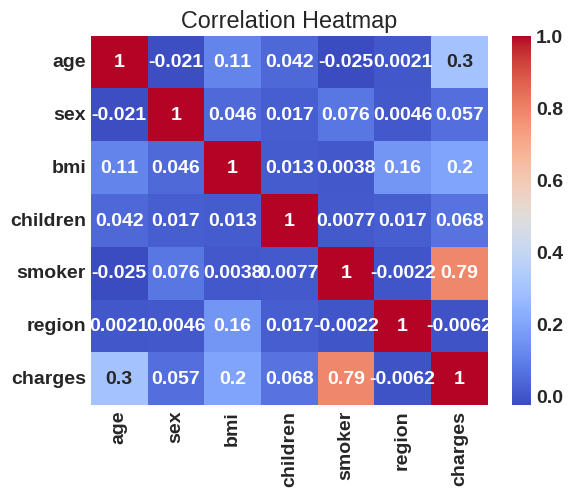

In [ ]:
corr = data.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Inference: Heatmap AFTER including encoded categorical features

(sex, smoker, region added)

What this heatmap says

Smoker vs Charges (≈ 0.79)
→ Very strong positive correlation
→ Smoking status is the strongest driver of medical charges.

Age vs Charges (≈ 0.30)
→ Still moderately correlated
→ Age remains an important factor.

BMI vs Charges (≈ 0.20)
→ Still shows a positive relationship.

Sex vs Charges (≈ 0.057)
→ Very weak correlation
→ Gender alone does not strongly affect charges.

Region vs Charges (≈ -0.006)
→ Almost no relationship
→ Region has negligible impact on medical cost.

Discovered that smoking dominates all other factors

Learned that region and sex have minimal impact

In [ ]:
print(data.select_dtypes(include='number').columns)


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


TASK 3

DATA PREPARATION AND DATA MODELLING

Convert Categorical Data into Numerical Form

In [ ]:
data_encoded = pd.get_dummies(data, drop_first=True)
#Converts sex, smoker, region into numeric dummy variables


In [ ]:
data_encoded.head()


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


Define X and y (from encoded data)

In [ ]:
# defining the explanatory (independent) and response (dependent) variables
X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']


In [ ]:
# splitting the data in 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,              # specifying the independent variables
    y,              # specifying the dependent variable
    test_size=0.20, # specifying the size of the test set as a fraction
    random_state=42 # specifying a seed value to enable reproducible results
)


Initialize the Linear Regression Model

In [ ]:
model = LinearRegression()    # create linear regression object


Train (Fit) the Model

In [ ]:
model.fit(X_train, y_train)   # model learns coefficients from training data


LinearRegression()

Simple Linear Regression: Charges vs Age

In [ ]:
from sklearn.linear_model import LinearRegression

# X and y
X = data_encoded[['age']]        # independent variable
y = data_encoded['charges']      # dependent variable

# model
model_age = LinearRegression()
model_age.fit(X, y)

# slope and intercept
slope = model_age.coef_[0]
intercept = model_age.intercept_

print("Charges vs Age")
print("Slope:", slope)
print("Intercept:", intercept)
print(f"Equation: charges = {slope:.2f}*age + {intercept:.2f}")


Charges vs Age
Slope: 257.72261866689564
Intercept: 3165.885006063021
Equation: charges = 257.72*age + 3165.89


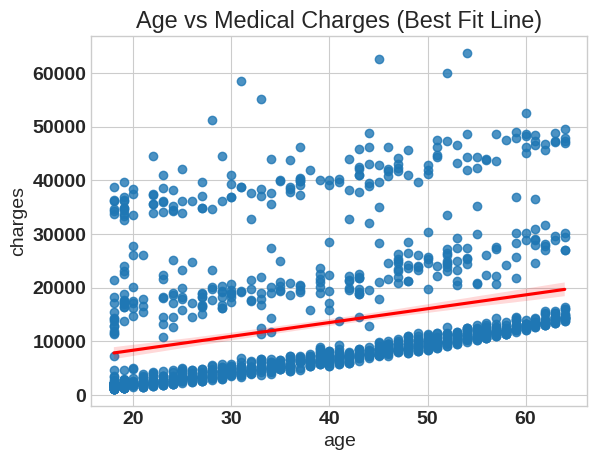

In [ ]:
sns.regplot(
    x='age',
    y='charges',
    data=data,
    line_kws={'color': 'red'}
)

plt.title("Age vs Medical Charges (Best Fit Line)")
plt.show()


📌 Charges vs Age – Interpretation

Equation: charges =
257.72
×
 age
+
 3165.89
charges = 257.72 × age + 3165.89


The value 257.72 means that for every 1 year increase in age, the medical charges increase by about 258 units on average.

The value 3165.89 represents the basic medical cost when age is very low.

From the scatter plot, we can see that charges generally increase as age increases, but the points are spread out. This means age affects charges, but it is not the only factor influencing medical expenses.

Simple Linear Regression: Charges vs BMI

In [ ]:
# X and y
X = data_encoded[['bmi']]        # independent variable
y = data_encoded['charges']      # dependent variable

# model
model_bmi = LinearRegression()
model_bmi.fit(X, y)

# slope and intercept
slope = model_bmi.coef_[0]
intercept = model_bmi.intercept_

print("\nCharges vs BMI")
print("Slope:", slope)
print("Intercept:", intercept)
print(f"Equation: charges = {slope:.2f}*bmi + {intercept:.2f}")



Charges vs BMI
Slope: 393.87303079739524
Intercept: 1192.9372089611497
Equation: charges = 393.87*bmi + 1192.94


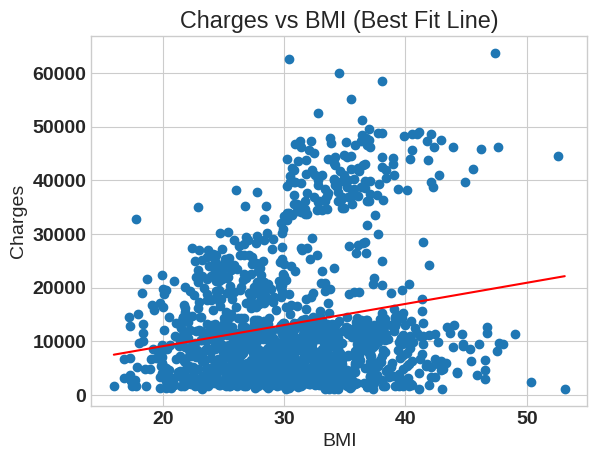

In [ ]:
X = data_encoded[['bmi']]
y = data_encoded['charges']

# train model
lr_bmi = LinearRegression()
lr_bmi.fit(X, y)

# predict best-fit line
y_pred = lr_bmi.predict(X)

# sort for clean line
sorted_idx = np.argsort(X.values.flatten())

# plot scatter (default color) and best-fit line (red)
plt.scatter(X.values.flatten(), y)
plt.plot(
    X.values.flatten()[sorted_idx],
    y_pred[sorted_idx],
    color='red'
)

plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('Charges vs BMI (Best Fit Line)')
plt.show()


📌 Charges vs BMI – Interpretation

Equation:charges=
393.87
×
bmi
+
1192.94
charges=393.87×bmi+1192.94

This equation shows how medical charges change with BMI.

The value 393.87 means that for every 1 unit increase in BMI, medical charges increase by about 394 units on average.

The value 1192.94 represents the basic medical cost when BMI is very low.

From the plot, we can see that the red line goes upward, which confirms a positive relationship between BMI and charges.
However, the points are widely spread around the line, showing that BMI alone does not decide the charges.

This means BMI affects medical costs, but other factors (like smoking and age) also have a strong influence.

Simple Linear Regression : Charges vs Children

In [ ]:
from sklearn.linear_model import LinearRegression

# select feature and target
X_children = data_encoded[['children']]   # independent variable
y = data_encoded['charges']               # dependent variable

# train simple linear regression model
lr_children = LinearRegression()
lr_children.fit(X_children, y)

# extract slope and intercept
slope_children = lr_children.coef_[0]
intercept_children = lr_children.intercept_

# print linear regression equation
print("Linear Regression Equation (Charges vs Children):")
print(f"charges = {slope_children:.2f}*children + {intercept_children:.2f}")


Linear Regression Equation (Charges vs Children):
charges = 683.09*children + 12522.50


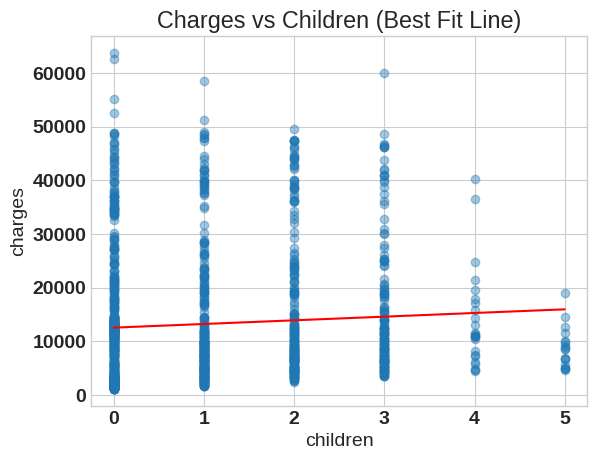

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# predict fitted values
y_pred = lr_children.predict(X_children)

# sort values for clean best-fit line
sorted_idx = np.argsort(X_children.values.flatten())

# plot scatter and regression line
plt.scatter(X_children, y, alpha=0.4)
plt.plot(
    X_children.values.flatten()[sorted_idx],
    y_pred[sorted_idx],
    color='red'
)

plt.xlabel('children')
plt.ylabel('charges')
plt.title('Charges vs Children (Best Fit Line)')
plt.show()


📌 Charges vs Children – Interpretation

Equation:charges=
683.09
×
children
+
12522.50
charges=683.09×children+12522.50

This equation shows how medical charges change with the number of children.

The value 683.09 means that for every additional child, medical charges increase by about 683 units on average.

The value 12522.50 represents the basic medical cost when the number of children is zero.

From the plot, we can see that the red line is almost flat and the points are widely spread. This shows that the number of children has very little effect on medical charges.

So, children is a weak predictor, and other factors influence charges much more.

Simple Linear Regression: Charges vs Smoker

In [ ]:
# X and y
X = data_encoded[['smoker']]   # independent variable
y = data_encoded['charges']       # dependent variable

# model
model_smoker = LinearRegression()
model_smoker.fit(X, y)

# slope and intercept
slope = model_smoker.coef_[0]
intercept = model_smoker.intercept_

print("\nCharges vs Smoker")
print("Slope:", slope)
print("Intercept:", intercept)
print(f"Equation: charges = {slope:.2f}*smoker + {intercept:.2f}")



Charges vs Smoker
Slope: 23615.96353367666
Intercept: 8434.2682978562
Equation: charges = 23615.96*smoker + 8434.27


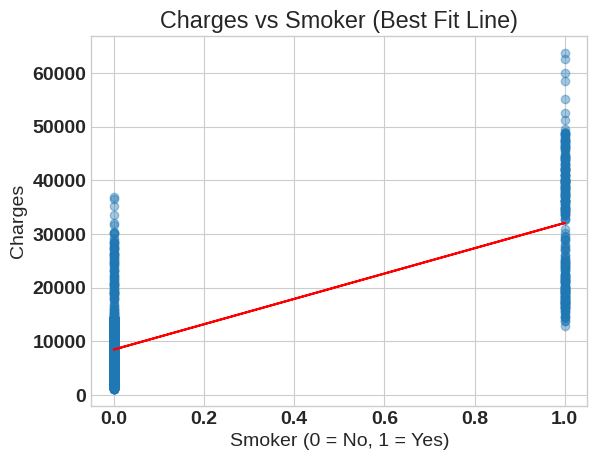

In [ ]:
# Simple Linear Regression: Charges vs Smoker

X = data_encoded[['smoker']]
y = data_encoded['charges']

# train model
lr_smoker = LinearRegression()
lr_smoker.fit(X, y)

# predict best-fit line
y_pred = lr_smoker.predict(X)

# plot scatter and best-fit line
plt.scatter(X, y, alpha=0.4)
plt.plot(X, y_pred, color='red')
plt.xlabel('Smoker (0 = No, 1 = Yes)')
plt.ylabel('Charges')
plt.title('Charges vs Smoker (Best Fit Line)')
plt.show()


📌 Charges vs Smoker – Interpretation

Equation:charges=
23615.96
×
smoker
+
8434.27
charges=23615.96×smoker+8434.27

Here, smoker = 0 means non-smoker and smoker = 1 means smoker.

The value 23615.96 shows that being a smoker increases medical charges by about 23,616 units on average compared to a non-smoker.

The value 8434.27 represents the average medical charge for a non-smoker.

From the plot, we can clearly see a big jump in charges from non-smokers to smokers.

This shows that smoking has a very strong effect on medical charges and is the most important factor among all features.

In [ ]:
# Simple Linear Regression: Charges vs Sex

X = data_encoded[['sex']]   # 0 = female, 1 = male
y = data_encoded['charges']

lr_sex = LinearRegression()
lr_sex.fit(X, y)

slope_sex = lr_sex.coef_[0]
intercept_sex = lr_sex.intercept_

print(f"Slope: {slope_sex}")
print(f"Intercept: {intercept_sex}")
print(f"Equation: charges = {slope_sex:.2f}*sex + {intercept_sex:.2f}")


Slope: 1387.1723338865465
Intercept: 12569.578843835348
Equation: charges = 1387.17*sex + 12569.58


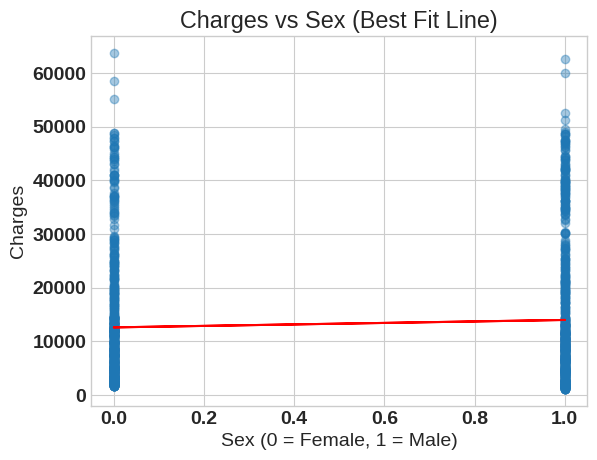

In [ ]:
y_pred = lr_sex.predict(X)

plt.scatter(X.values.flatten(), y, alpha=0.4)
plt.plot(X.values.flatten(), y_pred, color='red')

plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Charges')
plt.title('Charges vs Sex (Best Fit Line)')
plt.show()


📌 Charges vs Sex – Interpretation

Equation:charges=
1387.17
×
sex
+
12569.58
charges=1387.17×sex+12569.58

Here, sex = 0 represents female and sex = 1 represents male.

The value 1387.17 means that males spend about 1,387 units more on medical charges than females on average.

The value 12569.58 represents the average medical charge for females.

From the plot, the charges for males and females overlap heavily, showing no clear separation.

This means sex has only a small effect on medical charges and is a weak predictor compared to factors like smoking, age, and BMI.

In [ ]:
# Simple Linear Regression: Charges vs Region

X = data_encoded[['region']]   # encoded regions
y = data_encoded['charges']

lr_region = LinearRegression()
lr_region.fit(X, y)

slope_region = lr_region.coef_[0]
intercept_region = lr_region.intercept_

print(f"Slope: {slope_region}")
print(f"Intercept: {intercept_region}")
print(f"Equation: charges = {slope_region:.2f}*region + {intercept_region:.2f}")


Slope: -68.0449096995996
Intercept: 13373.557599125403
Equation: charges = -68.04*region + 13373.56


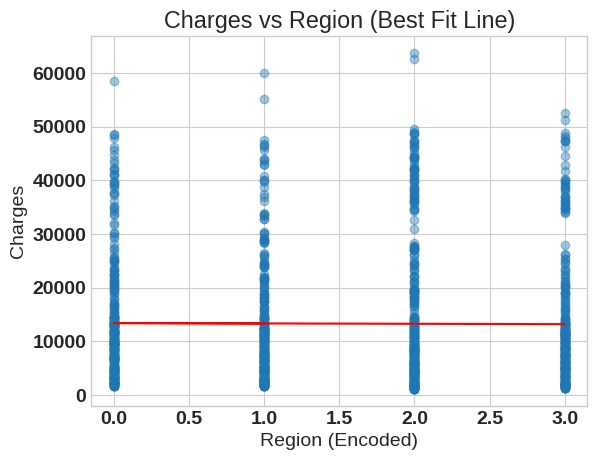

In [ ]:
y_pred = lr_region.predict(X)

plt.scatter(X.values.flatten(), y, alpha=0.4)
plt.plot(X.values.flatten(), y_pred, color='red')

plt.xlabel('Region (Encoded)')
plt.ylabel('Charges')
plt.title('Charges vs Region (Best Fit Line)')
plt.show()


📌 Charges vs Region – Interpretation

Equation:charges=
−
68.04
×
region
+
13373.56
charges=−68.04×region+13373.56

Here, region represents the encoded region values.

The slope –68.04 is very close to zero, which means that changing regions changes medical charges by only a very small amount.

The negative sign does not have real meaning here because region is a categorical variable that was encoded as numbers.

From the plot, medical charges across different regions look very similar.

This shows that region has almost no effect on medical charges and is a negligible predictor.

TASK 4

Multiple Linear Regression - Charges vs age , sex , bmi , children , smoker , region

Define X and y (Multiple Features vs Charges)

In [ ]:
# independent variables (all features)
X = data_encoded.drop('charges', axis=1)

# dependent variable
y = data_encoded['charges']


Train Multiple Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

# initialize model
mlr = LinearRegression()

# fit model
mlr.fit(X, y)


LinearRegression()

Extract Slopes (Coefficients) and Intercepts

In [ ]:
slopes = mlr.coef_
intercept = mlr.intercept_


Slopes with Feature Names

In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Slope': slopes
})

coeff_df


,Feature,Slope
0,age,257.288075
1,sex,-131.110580
2,bmi,332.570132
3,children,479.369394
4,smoker,23820.434123
5,region,-353.640017


Charges vs Age vs BMI

charges=257.28⋅age+332.57⋅bmi+c

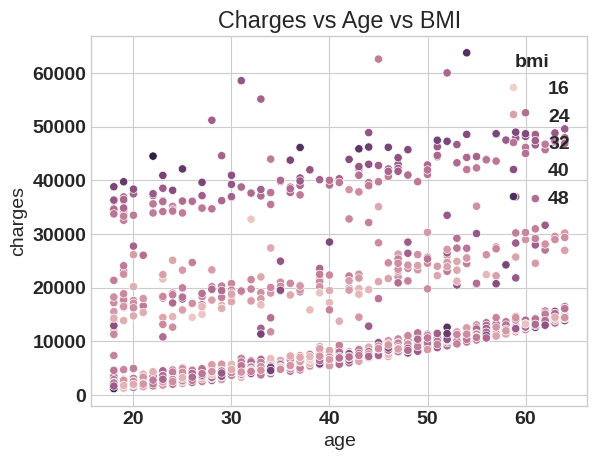

In [ ]:
sns.scatterplot(x='age', y='charges', hue='bmi', data=data)
plt.title("Charges vs Age vs BMI")
plt.show()


📌 Interpretation

Charges increase as age increases

Charges also increase as BMI increases

People who are older and have higher BMI tend to have higher medical charges

Both age and BMI have a moderate but clear effect

Charges vs Age vs BMI vs Children

charges=257.28⋅age+332.57⋅bmi+479.37⋅children+c

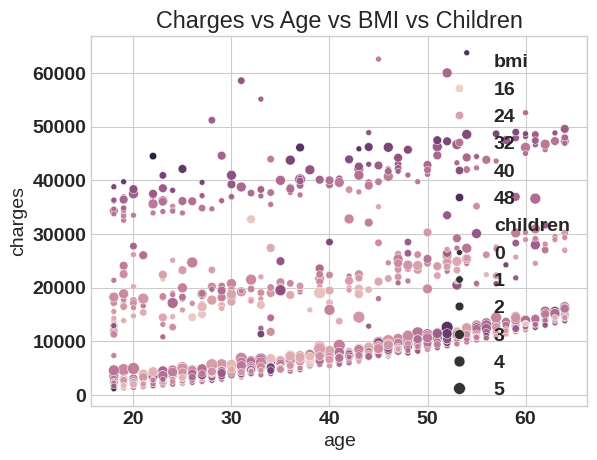

In [ ]:
sns.scatterplot(
    x='age', y='charges',
    hue='bmi', size='children',
    data=data
)
plt.title("Charges vs Age vs BMI vs Children")
plt.show()


📌 Interpretation

Age and BMI still clearly increase charges

Children increases charges slightly, but the effect is small

Even people with many children may have low charges

Children is a weak factor compared to age and BMI

Charges vs Age vs BMI vs Children vs Smoker

charges=257.28⋅age+332.57⋅bmi+479.37⋅children+23820.43⋅smoker+c

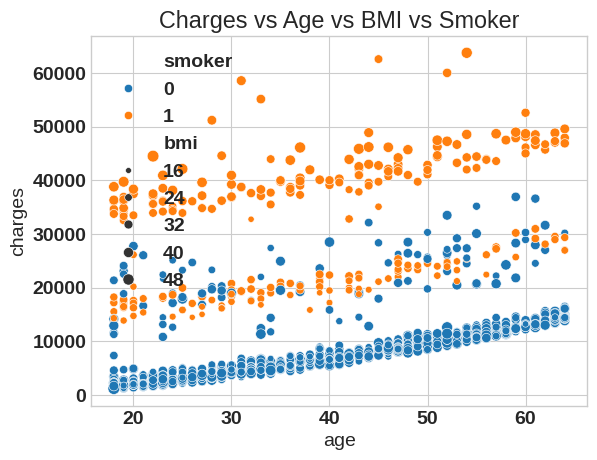

In [ ]:
sns.scatterplot(
    x='age', y='charges',
    hue='smoker', size='bmi',
    data=data
)
plt.title("Charges vs Age vs BMI vs Smoker")
plt.show()


Charges vs Age vs BMI vs Children vs Smoker vs Region

charges=257.28⋅age+332.57⋅bmi+479.37⋅children+23820.43⋅smoker−353.64⋅region+c

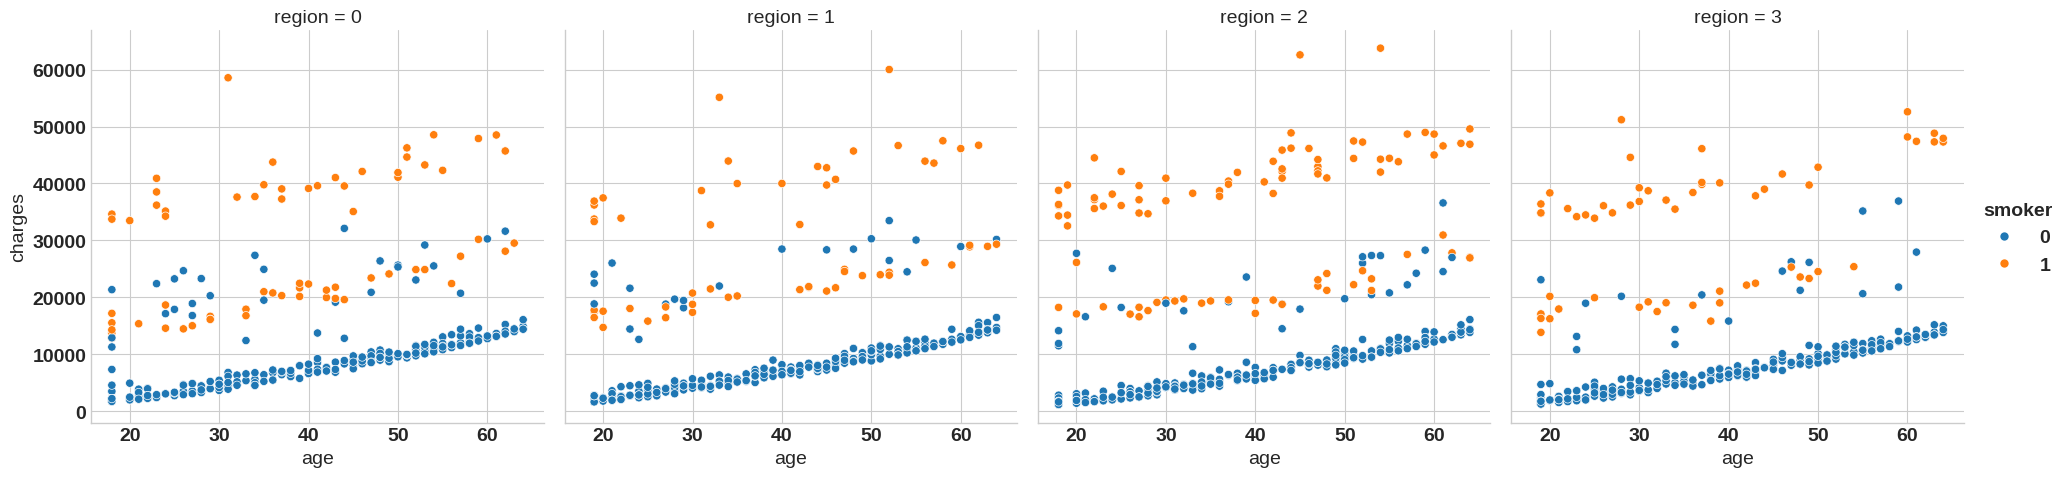

In [ ]:
sns.relplot(
    x='age', y='charges',
    hue='smoker', col='region',
    data=data, kind='scatter'
)


📌 Interpretation

Charge patterns look similar across all regions

Region changes charges only slightly

Smoking, age, and BMI still dominate

Region is a negligible factor

Charges vs Age vs BMI vs Children vs Smoker vs Region vs Sex

charges=257.28⋅age+332.57⋅bmi+479.37⋅children+23820.43⋅smoker−353.64⋅region−131.11⋅sex+c

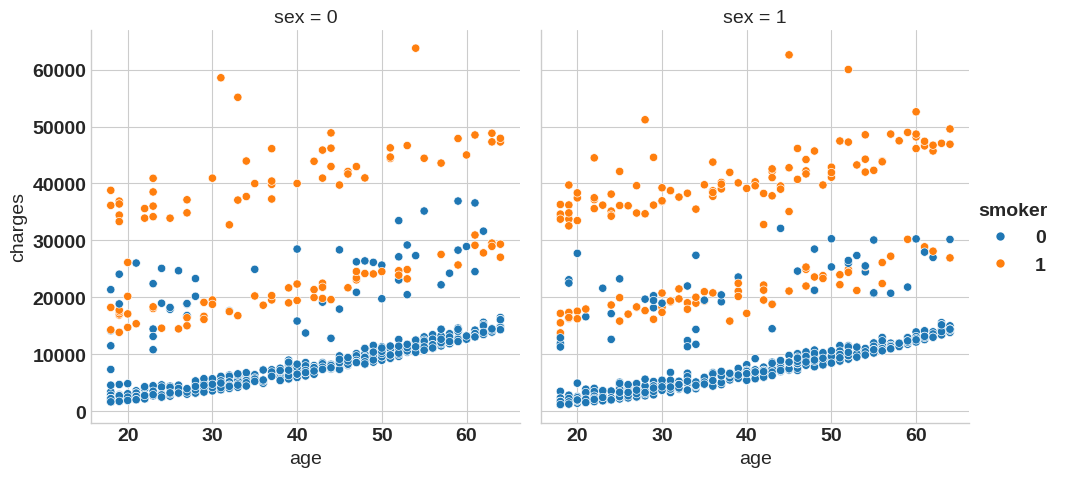

In [ ]:
sns.relplot(
    x='age', y='charges',
    hue='smoker', col='sex',
    data=data, kind='scatter'
)


📌 Interpretation

Both males and females show almost identical patterns

Sex changes charges by only ~131 units, which is very small

Smoking still dominates for both sexes

Sex is a very weak predictor

Generate the Multiple Linear Regression Equation

In [ ]:
equation = "charges = "

for coef, feature in zip(slopes, X.columns):
    equation += f"{coef:.2f}*{feature} + "

equation += f"{intercept:.2f}"

print(equation)


charges = 257.29*age + -131.11*sex + 332.57*bmi + 479.37*children + 23820.43*smoker + -353.64*region + -11815.45


TASK 5
MODEL PERFORMANCE EVALUATION


In [ ]:
# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]   # number of observations
    k = predictors.shape[1]   # number of predictors
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


In [ ]:
# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: trained regression model
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    # evaluation metrics
    rmse = np.sqrt(mean_squared_error(target, pred))   # RMSE
    mae = mean_absolute_error(target, pred)            # MAE
    mape = mape_score(target, pred)                    # MAPE
    r2 = r2_score(target, pred)                        # R-squared
    adj_r2 = adj_r2_score(predictors, target, pred)   # Adjusted R-squared

    # create dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": [rmse],
            "MAE": [mae],
            "MAPE": [mape],
            "R-squared": [r2],
            "Adj R-squared": [adj_r2],
        }
    )

    return df_perf


TASK 5
TRAIN DATA

SIMPLE LINEAR REGRESSION – Charges vs Age

In [ ]:
# independent variable
ind_vars1 = ['age']

# model
lin_reg1 = LinearRegression()
lin_reg1.fit(X_train[ind_vars1], y_train)

# TRAIN performance
lin_reg1_train_perf = model_performance_regression(
    lin_reg1, X_train[ind_vars1], y_train
)
lin_reg1_train_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,11527.28721,9042.420854,116.294374,0.079367,0.078505


In [ ]:
# TEST performance
lin_reg1_test_perf = model_performance_regression(
    lin_reg1, X_test[ind_vars1], y_test
)
lin_reg1_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,11661.215952,9173.258197,126.626634,0.12409,0.120797


SIMPLE LINEAR REGRESSION – Charges vs BMI

In [ ]:
# independent variable
ind_vars2 = ['bmi']

# model
lin_reg2 = LinearRegression()
lin_reg2.fit(X_train[ind_vars2], y_train)

# TRAIN performance
lin_reg2_train_perf = model_performance_regression(
    lin_reg2, X_train[ind_vars2], y_train
)
lin_reg2_train_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,11777.698282,9067.951789,148.041263,0.038934,0.038034


In [ ]:
# TEST performance
lin_reg2_test_perf = model_performance_regression(
    lin_reg2, X_test[ind_vars2], y_test
)
lin_reg2_test_perf



,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,12210.039191,9784.652596,170.350375,0.039702,0.036092


SIMPLE LINEAR REGRESSION – Charges vs Children

In [ ]:
# independent variable
ind_vars3 = ['children']

# model
lin_reg3 = LinearRegression()
lin_reg3.fit(X_train[ind_vars3], y_train)

# TRAIN performance
lin_reg3_train_perf = model_performance_regression(
    lin_reg3, X_train[ind_vars3], y_train
)
lin_reg3_train_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,11982.812075,9009.608295,145.628543,0.005167,0.004236


In [ ]:
# TEST performance
lin_reg3_test_perf = model_performance_regression(
    lin_reg3, X_test[ind_vars3], y_test
)
lin_reg3_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,12449.317774,9570.371167,163.861806,0.001695,-0.002058


SIMPLE LINEAR REGRESSION – Charges vs Smoker

In [ ]:
# independent variable
ind_vars4 = ['smoker']

# model
lin_reg4 = LinearRegression()
lin_reg4.fit(X_train[ind_vars4], y_train)

# TRAIN performance
lin_reg4_train_perf = model_performance_regression(
    lin_reg4, X_train[ind_vars4], y_train
)
lin_reg4_train_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,7517.11183,5698.568813,86.152917,0.608498,0.608131


In [ ]:
# TEST performance
lin_reg4_test_perf = model_performance_regression(
    lin_reg4, X_test[ind_vars4], y_test
)
lin_reg4_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,7262.641718,5625.810656,94.129036,0.660249,0.658971


MULTIPLE LINEAR REGRESSION – Charges vs Age + BMI

In [ ]:
ind_vars5 = ['age', 'bmi']

lin_reg5 = LinearRegression()
lin_reg5.fit(X_train[ind_vars5], y_train)

# TRAIN
lin_reg5_train_perf = model_performance_regression(
    lin_reg5, X_train[ind_vars5], y_train
)
lin_reg5_train_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,11355.239451,9021.931553,117.110608,0.106643,0.104968


In [ ]:
# TEST
lin_reg5_test_perf = model_performance_regression(
    lin_reg5, X_test[ind_vars5], y_test
)
lin_reg5_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,11464.739978,9222.664535,130.400231,0.153357,0.146967


MULTIPLE LINEAR REGRESSION – Charges vs Age + BMI + Smoker

In [ ]:
ind_vars6 = ['age', 'bmi', 'smoker']

lin_reg6 = LinearRegression()
lin_reg6.fit(X_train[ind_vars6], y_train)

# TRAIN
lin_reg6_train_perf = model_performance_regression(
    lin_reg6, X_train[ind_vars6], y_train
)
lin_reg6_train_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,6134.9873,4242.183082,43.453087,0.739229,0.738495


In [ ]:
# TEST
lin_reg6_test_perf = model_performance_regression(
    lin_reg6, X_test[ind_vars6], y_test
)
lin_reg6_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,5874.763304,4260.560091,49.570491,0.777693,0.775167


Charges vs Age vs BMI vs Smoker vs Region

In [ ]:
ind_vars3 = ['age', 'bmi', 'smoker',
             'region']

lin_reg3 = LinearRegression()
lin_reg3.fit(X_train[ind_vars3], y_train)

# TRAIN
lin_reg3_train_perf = model_performance_regression(
    lin_reg3, X_train[ind_vars3], y_train
)
lin_reg3_train_perf

# TEST
lin_reg3_test_perf = model_performance_regression(
    lin_reg3, X_test[ind_vars3], y_test
)
lin_reg3_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,5848.191826,4227.321526,48.626509,0.7797,0.776349


Charges vs Age vs BMI vs Smoker vs Region vs Sex

In [ ]:
ind_vars4 = ['age', 'bmi', 'smoker',
             'region',
             'sex']

lin_reg4 = LinearRegression()
lin_reg4.fit(X_train[ind_vars4], y_train)

# TRAIN
lin_reg4_train_perf = model_performance_regression(
    lin_reg4, X_train[ind_vars4], y_train
)
lin_reg4_train_perf

# TEST
lin_reg4_test_perf = model_performance_regression(
    lin_reg4, X_test[ind_vars4], y_test
)
lin_reg4_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,5848.151159,4227.246576,48.622752,0.779703,0.775499


Charges vs Age vs BMI vs Smoker vs Region vs Sex vs Children

In [ ]:
ind_vars5 = [
    'age', 'bmi', 'children', 'smoker',
    'region',
    'sex'
]

lin_reg5 = LinearRegression()
lin_reg5.fit(X_train[ind_vars5], y_train)

# TRAIN
lin_reg5_train_perf = model_performance_regression(
    lin_reg5, X_train[ind_vars5], y_train
)
lin_reg5_train_perf

# TEST
lin_reg5_test_perf = model_performance_regression(
    lin_reg5, X_test[ind_vars5], y_test
)
lin_reg5_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,5799.587091,4186.508898,47.09303,0.783346,0.778366


Multiple Linear Regression – Charges vs All Independent Variables

In [ ]:
# all independent variables
ind_vars7 = X.columns.tolist()

# model
lin_reg7 = LinearRegression()
lin_reg7.fit(X_train[ind_vars7], y_train)


LinearRegression()

In [ ]:
lin_reg7_train_perf = model_performance_regression(
    lin_reg7,
    X_train[ind_vars7],
    y_train
)

lin_reg7_train_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,6105.78932,4208.762029,42.246879,0.741705,0.740247


In [ ]:
lin_reg7_test_perf = model_performance_regression(
    lin_reg7,
    X_test[ind_vars7],
    y_test
)

lin_reg7_test_perf


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,5799.587091,4186.508898,47.09303,0.783346,0.778366


TASK 6
MODEL PERFORMANCE COMPARISON

In [ ]:
models_train_comp_df = pd.concat(
    [
        lin_reg1_train_perf.T,
        lin_reg2_train_perf.T,
        lin_reg3_train_perf.T,
        lin_reg4_train_perf.T,
        lin_reg5_train_perf.T,
        lin_reg6_train_perf.T,
        lin_reg7_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Simple LR - Charges vs Age",
    "Simple LR - Charges vs BMI",
    "Simple LR - Charges vs Children",
    "Simple LR - Charges vs Smoker",
    "Multiple LR - Charges vs Age, BMI",
    "Multiple LR - Charges vs Age, BMI, Smoker",
    "Multiple LR - Charges vs All Independent Variables",
]

print("Training Performance Comparison")
models_train_comp_df.T


Training Performance Comparison


,RMSE,MAE,MAPE,R-squared,Adj R-squared
Simple LR - Charges vs Age,11527.287210,9042.420854,116.294374,0.079367,0.078505
Simple LR - Charges vs BMI,11777.698282,9067.951789,148.041263,0.038934,0.038034
Simple LR - Charges vs Children,6127.511460,4239.397806,43.511043,0.739864,0.738887
Simple LR - Charges vs Smoker,6127.511400,4239.401017,43.510823,0.739864,0.738641
"Multiple LR - Charges vs Age, BMI",6105.789320,4208.762029,42.246879,0.741705,0.740247
"Multiple LR - Charges vs Age, BMI, Smoker",6134.987300,4242.183082,43.453087,0.739229,0.738495
Multiple LR - Charges vs All Independent Variables,6105.789320,4208.762029,42.246879,0.741705,0.740247


In [ ]:
lin_reg1_test_perf   # Charges vs Age
lin_reg2_test_perf   # Charges vs BMI
lin_reg3_test_perf   # Charges vs Children
lin_reg4_test_perf   # Charges vs Smoker
lin_reg5_test_perf   # Charges vs Age, BMI
lin_reg6_test_perf   # Charges vs Age, BMI, Smoker*
lin_reg7_test_perf   # Charges vs All variables


,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,5799.587091,4186.508898,47.09303,0.783346,0.778366


In [ ]:
models_test_comp_df = pd.concat(
    [
        lin_reg1_test_perf.T,
        lin_reg2_test_perf.T,
        lin_reg3_test_perf.T,
        lin_reg4_test_perf.T,
        lin_reg5_test_perf.T,
        lin_reg6_test_perf.T,
        lin_reg7_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Simple LR - Charges vs Age",
    "Simple LR - Charges vs BMI",
    "Simple LR - Charges vs Children",
    "Simple LR - Charges vs Smoker",
    "Multiple LR - Charges vs Age, BMI",
    "Multiple LR - Charges vs Age, BMI, Smoker",
    "Multiple LR - Charges vs All Independent Variables",
]

print("Test Performance Comparison")
models_test_comp_df.T

Test Performance Comparison


,RMSE,MAE,MAPE,R-squared,Adj R-squared
Simple LR - Charges vs Age,11661.215952,9173.258197,126.626634,0.124090,0.120797
Simple LR - Charges vs BMI,12210.039191,9784.652596,170.350375,0.039702,0.036092
Simple LR - Charges vs Children,5848.191826,4227.321526,48.626509,0.779700,0.776349
Simple LR - Charges vs Smoker,5848.151159,4227.246576,48.622752,0.779703,0.775499
"Multiple LR - Charges vs Age, BMI",5799.587091,4186.508898,47.093030,0.783346,0.778366
"Multiple LR - Charges vs Age, BMI, Smoker",5874.763304,4260.560091,49.570491,0.777693,0.775167
Multiple LR - Charges vs All Independent Variables,5799.587091,4186.508898,47.093030,0.783346,0.778366


In [ ]:
feature_test_perf = pd.concat(
    [
        lin_reg1_test_perf.T,
        lin_reg2_test_perf.T,
        lin_reg3_test_perf.T,
        lin_reg4_test_perf.T,
    ],
    axis=1,
)

feature_test_perf.columns = [
    "Age",
    "BMI",
    "Children",
    "Smoker"
]

feature_test_perf = feature_test_perf.T

feature_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
Age,11661.215952,9173.258197,126.626634,0.124090,0.120797
BMI,12210.039191,9784.652596,170.350375,0.039702,0.036092
Children,5848.191826,4227.321526,48.626509,0.779700,0.776349
Smoker,5848.151159,4227.246576,48.622752,0.779703,0.775499


In [ ]:
lin_reg1_test_perf

,RMSE,MAE,MAPE,R-squared,Adj R-squared
0,11661.215952,9173.258197,126.626634,0.12409,0.120797


In [ ]:
print(feature_test_perf.columns)

Index(['RMSE', 'MAE', 'MAPE', 'R-squared', 'Adj R-squared'], dtype='object')


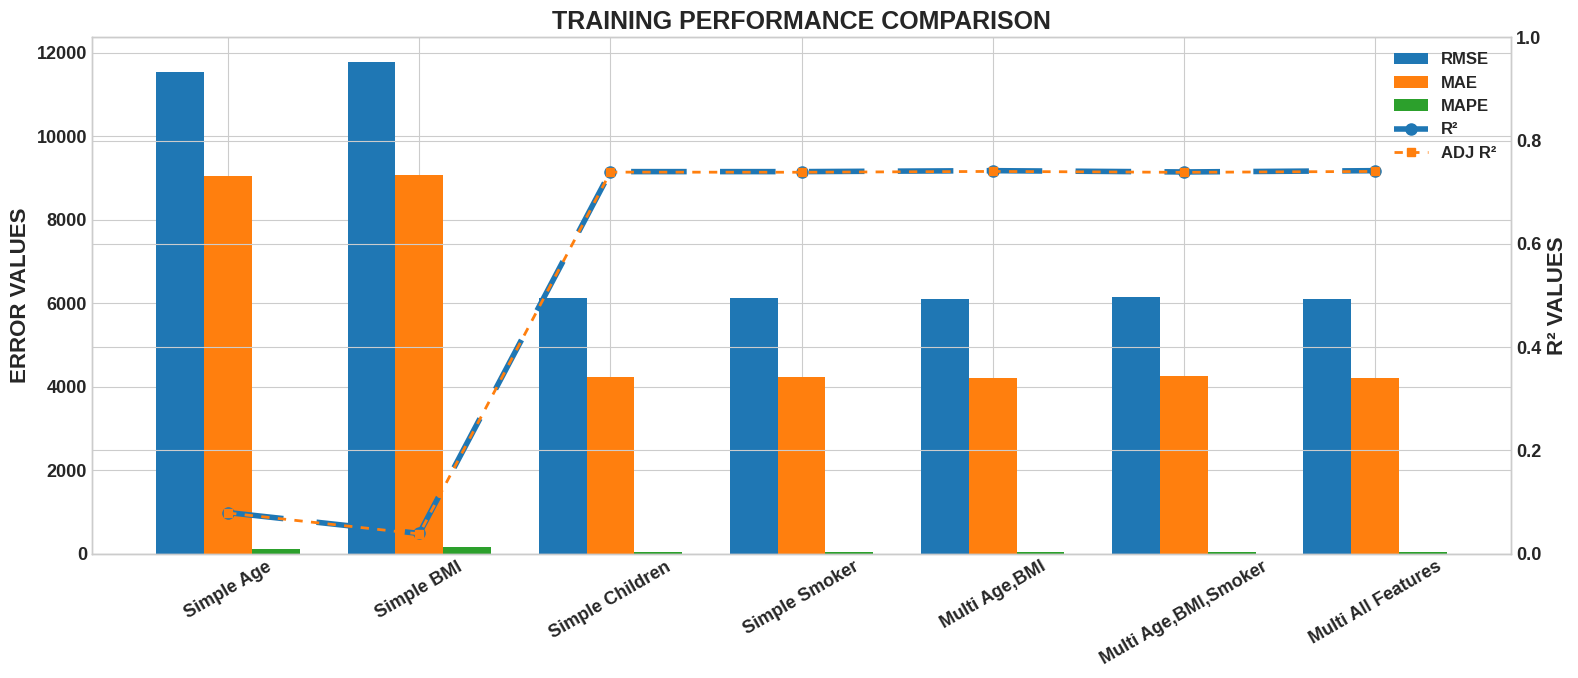

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Global font settings (Big + Bold)
plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold"
})

models = [
    "Simple Age",
    "Simple BMI",
    "Simple Children",
    "Simple Smoker",
    "Multi Age,BMI",
    "Multi Age,BMI,Smoker",
    "Multi All Features"
]

rmse = [11527.287210, 11777.698282, 6127.511460, 6127.511400,
        6105.789320, 6134.987300, 6105.789320]

mae = [9042.420854, 9067.951789, 4239.397806, 4239.401017,
       4208.762029, 4242.183082, 4208.762029]

mape = [116.294374, 148.041263, 43.511043, 43.510823,
        42.246879, 43.453087, 42.246879]

r2 = [0.079367, 0.038934, 0.739864, 0.739864,
      0.741705, 0.739229, 0.741705]

adj_r2 = [0.078505, 0.038034, 0.738887, 0.738641,
          0.740247, 0.738495, 0.740247]

x = np.arange(len(models))
width = 0.25

fig, ax1 = plt.subplots(figsize=(16,7))

# --- Error Bars ---
ax1.bar(x - width, rmse, width, label='RMSE')
ax1.bar(x, mae, width, label='MAE')
ax1.bar(x + width, mape, width, label='MAPE')

ax1.set_ylabel("ERROR VALUES", fontsize=16, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, fontweight='bold')



# --- R² Axis ---
ax2 = ax1.twinx()

# R² → Bold long dashed
ax2.plot(x, r2,
         linestyle=(0, (10, 6)),
         linewidth=4,
         marker='o',
         markersize=8,
         label='R²')

# Adjusted R² → Small dashed thinner
ax2.plot(x, adj_r2,
         linestyle=(0, (3, 3)),
         linewidth=2,
         marker='s',
         markersize=6,
         label='ADJ R²')

ax2.set_ylabel("R² VALUES", fontsize=16, fontweight='bold')
ax2.set_ylim(0, 1)

# Bold tick labels
ax1.tick_params(labelsize=13)
ax2.tick_params(labelsize=13)

# --- Combined Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right',
           prop={'weight':'bold', 'size':12})

plt.title("TRAINING PERFORMANCE COMPARISON",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()
plt.show()

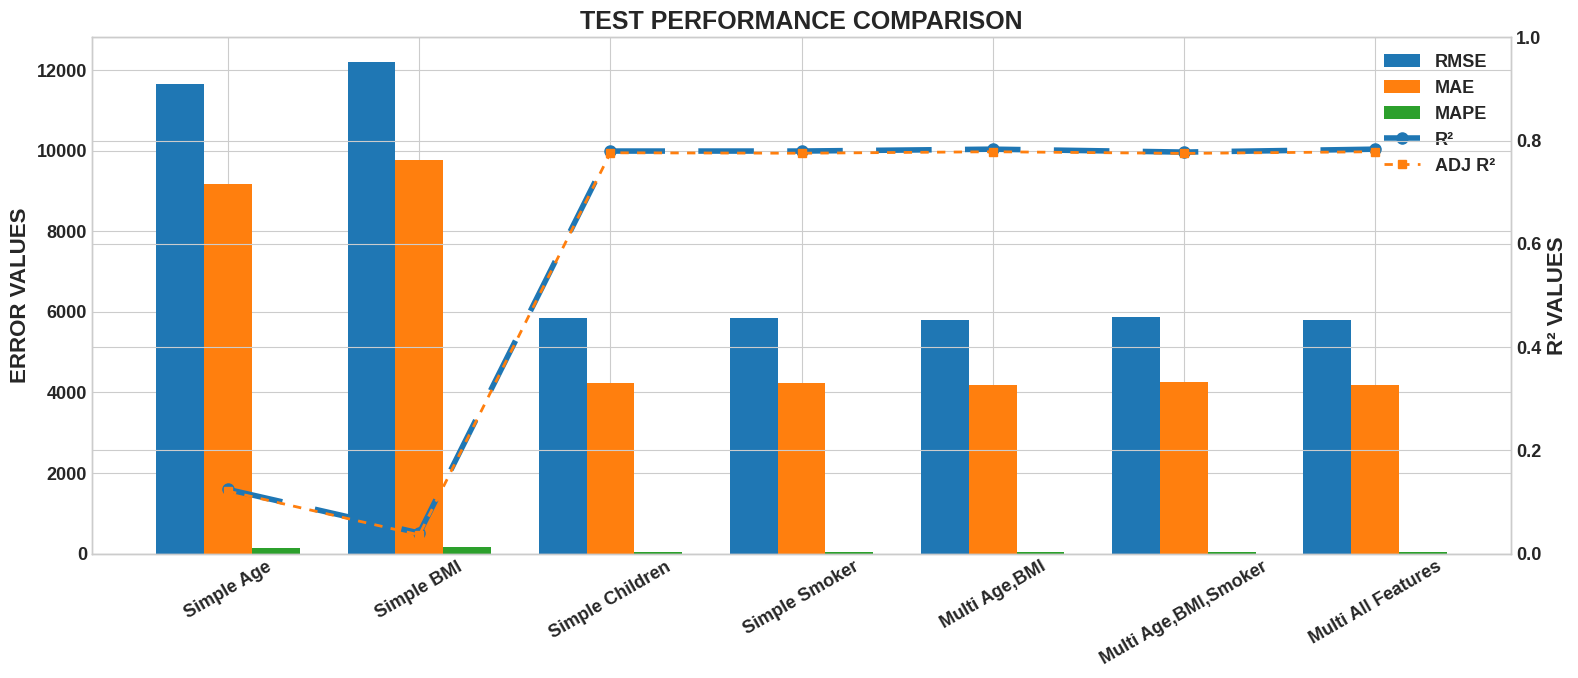

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Global font settings (Big + Bold)
plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold"
})

models = [
    "Simple Age",
    "Simple BMI",
    "Simple Children",
    "Simple Smoker",
    "Multi Age,BMI",
    "Multi Age,BMI,Smoker",
    "Multi All Features"
]

rmse = [11661.215952, 12210.039191, 5848.191826, 5848.151159,
        5799.587091, 5874.763304, 5799.587091]

mae = [9173.258197, 9784.652596, 4227.321526, 4227.246576,
       4186.508898, 4260.560091, 4186.508898]

mape = [126.626634, 170.350375, 48.626509, 48.622752,
        47.093030, 49.570491, 47.093030]

r2 = [0.124090, 0.039702, 0.779700, 0.779703,
      0.783346, 0.777693, 0.783346]

adj_r2 = [0.120797, 0.036092, 0.776349, 0.775499,
          0.778366, 0.775167, 0.778366]

x = np.arange(len(models))
width = 0.25

fig, ax1 = plt.subplots(figsize=(16,7))

# --- Error Metric Bars ---
ax1.bar(x - width, rmse, width, label='RMSE')
ax1.bar(x, mae, width, label='MAE')
ax1.bar(x + width, mape, width, label='MAPE')

ax1.set_ylabel("ERROR VALUES", fontsize=16, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, fontweight='bold')



# --- R² Axis ---
ax2 = ax1.twinx()

# R² → Bold long dashed
ax2.plot(x, r2,
         linestyle=(0, (10, 6)),
         linewidth=4,
         marker='o',
         markersize=8,
         label='R²')

# Adjusted R² → Small dashed thinner
ax2.plot(x, adj_r2,
         linestyle=(0, (3, 3)),
         linewidth=2,
         marker='s',
         markersize=6,
         label='ADJ R²')

ax2.set_ylabel("R² VALUES", fontsize=16, fontweight='bold')
ax2.set_ylim(0, 1)

# Bold tick labels
ax1.tick_params(labelsize=13)
ax2.tick_params(labelsize=13)

# --- Combined Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right',
           prop={'weight':'bold', 'size':13})

plt.title("TEST PERFORMANCE COMPARISON",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()
plt.show()

# Final Linear Regression Model (All Features)

The final multi-feature Linear Regression model achieved an R² score of 0.74, indicating that approximately 74% of the variance in insurance charges is explained by the selected features. The model demonstrates moderate predictive performance, with smoking status emerging as the strongest contributing factor.

**COEFFICIENT INTERPRETATION**

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_df

,Feature,Coefficient
0,age,257.056264
1,sex,-18.791457
2,bmi,335.781491
3,children,425.091456
4,smoker,23647.818096
5,region,-271.284266


Positive coefficient → Insurance charges increase as the feature value increases (keeping other variables constant).

Negative coefficient → Insurance charges decrease as the feature value increases.

Larger coefficient magnitude → Stronger impact on insurance charges.

**Residual Analysis**

In [ ]:
y_pred = model.predict(X_test)

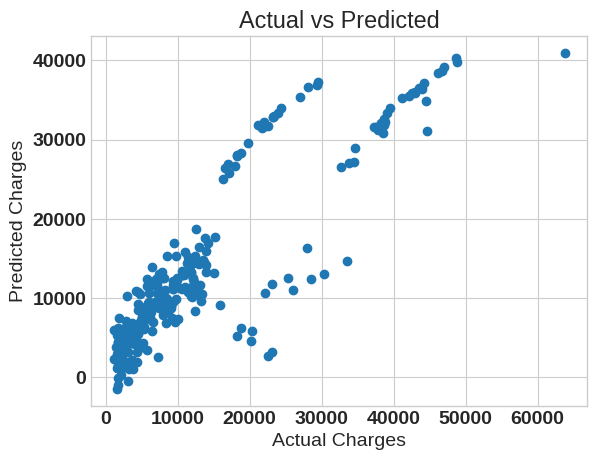

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import pickle

with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
from google.colab import files
files.download("linear_regression_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Conclusion

The Linear Regression model explains approximately 74% of the variance in medical insurance charges. Smoking status is the most influential factor, significantly increasing insurance costs. Age and BMI also contribute moderately to the prediction. The model demonstrates reasonable predictive capability and can be further improved using regularization techniques or advanced regression models.